1788.8789372016158 23.07436888191704


C:\Users\sonic\AppData\Local\Temp\ipykernel_20980\1455015339.py:119: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='proton path', color = 'blue')


The electron path is more curved because its mass is significantly smaller than the proton so it is easier to accelerate compared to a proton


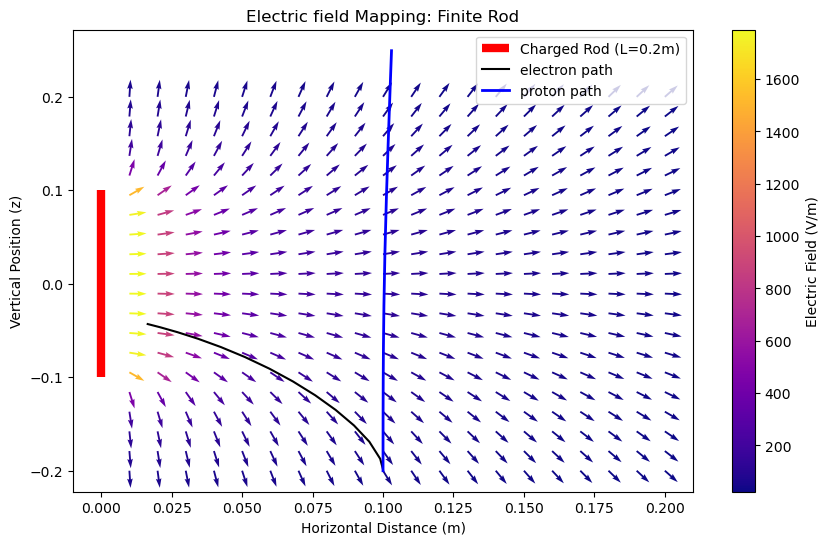

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.integrate import solve_ivp
# Task 1
k_coulomb = 8.99e9  # N m^2 / C^2
lam=1e-9

def calculate_electric_field_Z(y_obs, z_obs, L=0.2, lam=1e-9): # Y compnent of electric field

     # We define the integrand for the electric field vector: Ey = y dz^(prime)/ r^3 , Ey = (z-z^(prime)) dz^(prime)/ r^3
    #(z-z^(prime)): horizontal distance from point charge to observed z-value on the rod
    # r = sqrt(y_obs^2 + (z_obs - z_rod)^2)
    # r^3 = (sqrt(y_obs^2 + (z_obs - z_rod)^2))^3
    def integrand_Z(z_rod):    # Integrand for Z_component
        r_dist = np.sqrt(y_obs**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (z_obs- z_rod) / r_cubed 
    n_segments = 100   # how many segments to divide it into
    z_points = np.linspace(-L/2 , L/2, n_segments)
    vZ_values = integrand_Z(z_points)
    integral_z = trapezoid(vZ_values, z_points)
    Ez = k_coulomb * lam * integral_z
    return Ez

def calculate_electric_field_Y(y_obs, z_obs, L=0.2, lam=1e-9): # Y compnent of electric field
    def integrand_Y(z_rod): # Integrand for Y_component
        r_dist = np.sqrt(y_obs**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return y_obs / r_cubed 
    n_segments = 209  # how many segments to divide it into,(set to 209 for task 4)
    z_points = np.linspace(-L/2, L/2, n_segments) 
    vY_values = integrand_Y(z_points)  
    # Use the trapezoid rule to sum the contributions
    integral_y = trapezoid(vY_values, z_points)
    Ey = k_coulomb * lam * integral_y
    return Ey
#Returned Ey and Ex, so it would be easier to do math with the function

# 1. SETUP THE GRID (YZ-Plane)
y = np.linspace(0.01, 0.20, 20)  # Perpendicular distance from the rod
z = np.linspace(-0.2, 0.2, 20)  # Position along/parallel to the rod
Y, Z = np.meshgrid(y, z)

# 2. CALCULATE Z AND Y components of the E-field AT EVERY GRID POINT
Ey_map = np.zeros(Y.shape)   #shape of Y
Ez_map = np.zeros(Z.shape)   #shape of Z
E_mag = np.zeros(Y.shape) # set 

for i in range(len(z)):   #len = length function looks at how many data points are in z_range 
    for j in range(len(y)): 
        E_mag[i,j] = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # array magnitude to allow for E_mag to be used on color map
        E_mag_x = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # scalar just to normalize data
        Ey_map[i,j] = calculate_electric_field_Y(Y[i,j], Z[i,j])/E_mag_x # Normlizes the data
        Ez_map[i,j] = calculate_electric_field_Z(Y[i,j], Z[i,j])/E_mag_x
       

print(E_mag.max(), E_mag.min()) #Just to check if the E_mag is changing

# Task 2
qe= -1.602e-19
qp = 1.602e-19
me = 9.1e-31
mp = 1.67e-27

def electron(t, state):  
    #Fe = qE, ma = qE, a = qE/m
    y, z, vy, vz = state
    r_dist = np.sqrt((y)**2 + (z)**2)  #Z/-rod is changing
    r_cubed = (r_dist)**3
    Ey = calculate_electric_field_Y(y, z)  # already scaled correctly
    Ez = calculate_electric_field_Z(y, z)  # use function above and the equation Fe = qE to solve for acceleration
    az = (Ez* qe)/me
    ay = (Ey* qe)/me
    return [vy, vz, ay, az]

def proton(t, state):
    y, z, vy, vz = state
    r_dist = np.sqrt((y)**2 + (z)**2)  
    r_cubed = (r_dist)**3
    Ey_p = calculate_electric_field_Y(y, z)  
    Ez_p = calculate_electric_field_Z(y, z)
    az = (Ez_p* qp)/mp
    ay = (Ey_p* qp)/mp
    return [vy, vz, ay, az]
   
y0 = [0.1, -0.2, 0.0, 5e5]  # state
t_span = (0, 1.4e-7)  # time span for electron
t_span_p = (0, 9e-7) # time span for proton
# anything with _p is for the proton

sol = solve_ivp(electron, t_span, y0, method='RK45', rtol=1e-6)
sol_p = solve_ivp(proton, t_span_p, y0, method='RK45', rtol=1e-6)

# Extract the internal steps
#t_steps = sol.t
z_steps = sol.y[1]
y_steps = sol.y[0]

zp_steps = sol_p.y[1]
yp_steps = sol_p.y[0]



#plots


plt.figure(figsize=(10, 6))
cp = plt.quiver(Y, Z, Ey_map, Ez_map, E_mag, cmap='plasma')
# Y,Z = origin point of where the vectors will be placed,  Ey_map,Ex_map = x and y components of vectors, E_mag sets the color map to the changing values of E_mag
plt.colorbar(cp, label='Electric Field (V/m)')
# Draw the charged rod
plt.vlines(0, -0.1, 0.1, color='red', linewidth=6, label= 'Charged Rod (L=0.2m)')
plt.title("Electric field Mapping: Finite Rod")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Position (z)")

plt.plot(y_steps, z_steps, 'k-',alpha = 1, linewidth=1.5, label='electron path')
plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='proton path', color = 'blue')
plt.legend()

'''
Analysis: Why does the electron path look so much more "curved" than the proton path,
even though they experience the same magnitude of field?
'''
print("The electron path is more curved because its mass is significantly smaller than the proton so it is easier to accelerate compared to a proton")


In [87]:
#Task 3

# ---very far distance
# Ey = k * lam * integral( y/ (np.sqrt((y)**2 + (z)**2)^2)^3 dz)  [from -l/2 to l/2]
# sense y is far, the rod is treated like a point charge, and z = 0
# k* lam * y * integral(y/(np.sqrt((y)**2 + 0))^3 dz) =   k * lam * integral( 1/y**2 dz) = k*lam * (1/y**2) * integral(dz) [from -l/2 to l/2]
# Ey = k*lam*(1/y**2)*l
z = 0
L = 0.2
k_coulomb = 8.99e9  # N m^2 / C^2
lam=1e-9
y_far = 5
r_far = np.sqrt((y_far)**2 + (z)**2)  #Z/-rod is changing
r_far3 = (r_far)**3
Ey_calc = k_coulomb * lam * (y_far/(r_far3)) * L
print("The numerical result: ",Ey_calc)
Ey_func= calculate_electric_field_Y(y_far, z)
print("My result (Function): ",Ey_func)


#---very close distance
#Z = 0, because it's the farthest away from both edges and simulates an infinte rod the best
y_2 = 0.001
Ey_small = (2*k_coulomb*lam)/y_2 # Guass's law for an infinte charge
Ey2_func= calculate_electric_field_Y(y_2, z)
print("The numerical result: ",Ey_small)
print("My result (function): ",Ey2_func)

The numerical result:  0.07192000000000001
My result (Function):  0.07190561964948575
The numerical result:  17980.0
My result (function):  18155.98348324101


In [91]:
'''
Task 4: Physical Discussion (The "Why")
1. Symmetry: Why is a 2D slice (Y, Z) sufficient to understand the field of a 3D cylindrical
rod?

2. Convergence: How many segments did you need in your trapezoid call before the
"Infinite Line Limit" error dropped below 1%?
'''
#1
print("A 2D slice is sufficient because the math for calculating a magnetic field is the same for all dimensional components, Y,Z, and X")
print("Similaraly to how above I constructed a Electric field through using the same equation to calculate the Y and Z components, having a 2D")
print("slice is sufficent because the equations used to represent the 2D slice can be applied to the 3rd dimension to understand a 3D cylindrical rod")
print("  ") # spacing between anwsers
#2
error = ((Ey2_func-Ey_small)/Ey_small) * 100   # error equation
# I manually changed the values to see when it dropped below 1%
print("When n-segments is set to 209 the error drops below 1% so 209 is thelimit. At 209 it goes to ", round(error, 3))




A 2D slice is sufficient because the math for calculating a magnetic field is the same for all dimensional components, Y,Z, and X
Similaraly to how above I constructed a Electric field through using the same equation to calculate the Y and Z components, having a 2D
slice is sufficent because the equations used to represent the 2D slice can be applied to the 3rd dimension to understand a 3D cylindrical rod
  
When n-segments is set to 209 the error drops below 1% so 209 is the, at 209 it goes to  0.979


C:\Users\sonic\AppData\Local\Temp\ipykernel_20980\1926378244.py:99: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='Pendulum Angle', color= 'blue')


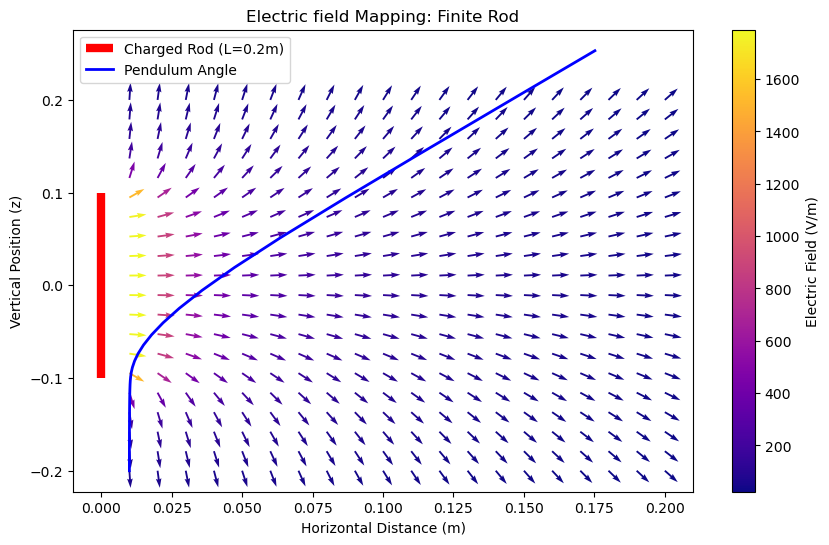

In [25]:
def calculate_electric_field_Z(y_obs, z_obs, L=0.2, lam=1e-9): # Y compnent of electric field
    def integrand_Z(z_rod):    # Integrand for Z_component
        r_dist = np.sqrt(y_obs**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (z_obs- z_rod) / r_cubed 
    n_segments = 100   # how many segments to divide it into
    z_points = np.linspace(-L/2 , L/2, n_segments)
    vZ_values = integrand_Z(z_points)
    integral_z = trapezoid(vZ_values, z_points)
    Ez = k_coulomb * lam * integral_z
    return Ez

def calculate_electric_field_Y(y_obs, z_obs, L=0.2, lam=1e-9): # Y compnent of electric field
    def integrand_Y(z_rod): # Integrand for Y_component
        r_dist = np.sqrt(y_obs**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return y_obs / r_cubed 

    # Discretize the rod into segments for integration
    # need to have unique points and values for z and y components
    n_segments = 209  # how many segments to divide it into
    z_points = np.linspace(-L/2, L/2, n_segments)
    vY_values = integrand_Y(z_points)  
    # Use the trapezoid rule to sum the contributions
    integral_y = trapezoid(vY_values, z_points)
    Ey = k_coulomb * lam * integral_y
    return Ey

# 1. SETUP THE GRID (YZ-Plane)
y = np.linspace(0.01, 0.20, 20)  # Perpendicular distance from the rod
z = np.linspace(-0.2, 0.2, 20)  # Position along/parallel to the rod
Y, Z = np.meshgrid(y, z)

# 2. CALCULATE Z AND Y components of the E-field AT EVERY GRID POINT
Ey_map = np.zeros(Y.shape)   #shape of Y
Ez_map = np.zeros(Z.shape)   #shape of Z
E_mag = np.zeros(Y.shape) # set 

for i in range(len(z)):   #len = length function looks at how many data points are in z_range 
    for j in range(len(y)): 
        E_mag[i,j] = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # array magnitude to allow for E_mag to be used on color map
        E_mag_x = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # scalar just to normalize data
        Ey_map[i,j] = calculate_electric_field_Y(Y[i,j], Z[i,j])/E_mag_x # Normlizes the data
        Ez_map[i,j] = calculate_electric_field_Z(Y[i,j], Z[i,j])/E_mag_x

qp = 1.602e-19
mp = 1.67e-27

def proton(t, state):
    y, z, vy, vz = state
    r_dist = np.sqrt((y)**2 + (z)**2)  #Z/-rod is changing
    r_cubed = (r_dist)**3
    Ey_p = calculate_electric_field_Y(y, z)  # already scaled correctly
    Ez_p = calculate_electric_field_Z(y, z)
    az = (Ez_p* qp)/mp
    ay = (Ey_p* qp)/mp
    return [vy, vz, ay, az]


y0 = [0.01, -0.2, 0.0, 1.7e5] # made proton closer to rod 

t_span_p = (0,3e-6)

sol_p = solve_ivp(proton, t_span_p, y0, method='RK45', rtol=1e-6)

zp_steps = sol_p.y[1]
yp_steps = sol_p.y[0]

#plots

plt.figure(figsize=(10, 6))
cp = plt.quiver(Y, Z, Ey_map, Ez_map, E_mag, cmap='plasma')
# Y,Z = origin point of where the vectors will be placed,  Ey_map,Ex_map = x and y components of vectors, E_mag sets the color map to the changing values of E_mag
plt.colorbar(cp, label='Electric Field (V/m)')
# Draw the charged rod
plt.vlines(0, -0.1, 0.1, color='red', linewidth=6, label= 'Charged Rod (L=0.2m)')
plt.title("Electric field Mapping: Finite Rod")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Position (z)")
plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='Proton path', color= 'blue')
plt.legend()
   

12957.093464376376 31.9091251226867


C:\Users\sonic\AppData\Local\Temp\ipykernel_20980\2364256545.py:132: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='Pendulum Angle', color= 'blue')


AttributeError: module 'matplotlib.pyplot' has no attribute 'leg'

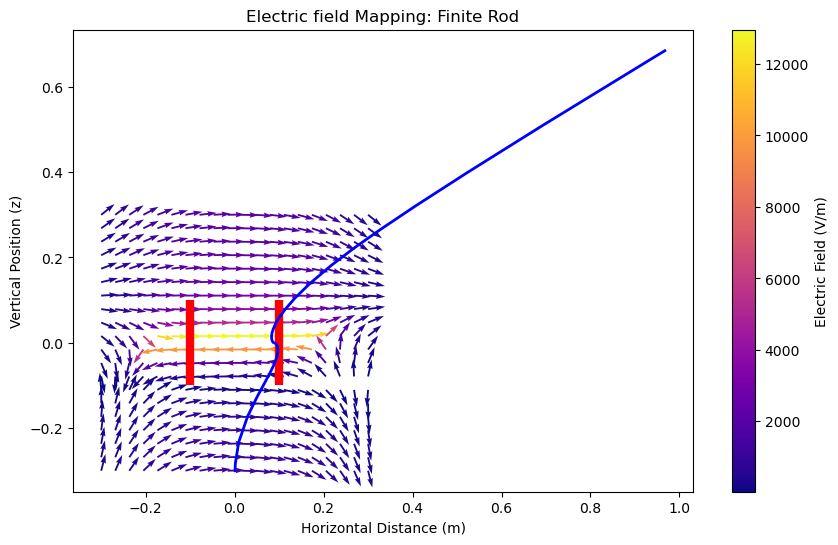

In [54]:
#task 6

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.integrate import solve_ivp

k_coulomb = 8.99e9  # N m^2 / C^2

def calculate_electric_field_Z(z_obs, y_obsA = 0.1, y_obsB = -0.1, L=0.2, lamA=1e-8, lamB = -1e-8): # Y compnent of electric field
# independtly calculated the integrand and integral of each rod and then summed the final value of their respective calculated E-fields
# sense there are two rods
    def integrand_ZA(z_rod):    # Integrand for Z_component
        r_dist = np.sqrt(y_obsA**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (z_obs- z_rod) / r_cubed 
    def integrand_ZB(z_rod):    # Integrand for Z_component
        r_dist = np.sqrt(y_obsB**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (z_obs- z_rod) / r_cubed 
    
    n_segments = 100   # how many segments to divide it into
    z_points = np.linspace(-L , L, n_segments)
    vZB_values = integrand_ZB(z_points)
    vZA_values = integrand_ZA(z_points)
    integral_zA = trapezoid(vZA_values, z_points)
    integral_zB = trapezoid(vZB_values, z_points)
    EzB = k_coulomb * lamB * integral_zB
    EzA = k_coulomb * lamA * integral_zA
    Net_Ez = EzB+EzA
    return Net_Ez

def calculate_electric_field_Y(z_obs, y_obsA = 0.1, y_obsB = -0.1, L=0.2, lamA=1e-8, lamB = -1e-8): # Y compnent of electric field

    def integrand_YA(z_rod): # Integrand for Y_component
        r_dist = np.sqrt(y_obsA**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return y_obsA / r_cubed 
    def integrand_YB(z_rod): # Integrand for Y_component
        r_dist = np.sqrt(y_obsB**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return y_obsB / r_cubed 

    
    n_segments = 100  # how many segments to divide it into
    z_points = np.linspace(-L, L, n_segments)
    vY_valuesA = integrand_YA(z_points)  
    vY_valuesB= integrand_YB(z_points)
    # Use the trapezoid rule to sum the contributions
    integral_yA = trapezoid(vY_valuesA, z_points)
    integral_yB = trapezoid(vY_valuesB, z_points)
    EyB = k_coulomb * lamB * integral_yB
    EyA = k_coulomb * lamA * integral_yA
    Net_Ey = EyB+EyA
    return Net_Ey
#Returned Ey and Ex so it would be easier to do math with the function
#E_mag = np.sqrt((Ey)**2 + (Ez)**2)  # combine z and y components in the end with magnitude equation


# 1. SETUP THE GRID (YZ-Plane)
y = np.linspace(-0.3, 0.30, 20)  # Perpendicular distance from the rod
z = np.linspace(-0.3, 0.3, 20)  # Position along/parallel to the rod
Y, Z = np.meshgrid(y, z)

# 2. CALCULATE Z AND Y components of the E-field AT EVERY GRID POINT
Ey_map = np.zeros(Y.shape)   #shape of Y
Ez_map = np.zeros(Z.shape)   #shape of Z
E_mag = np.zeros(Y.shape) # set 

for i in range(len(z)):   #len = length function looks at how many data points are in z_range 
    for j in range(len(y)): 
        E_mag[i,j] = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # array magnitude to allow for E_mag to be used on color map
        E_mag_x = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # scalar just to normalize data
        Ey_map[i,j] = calculate_electric_field_Y(Y[i,j], Z[i,j])/E_mag_x # Normlizes the data
        Ez_map[i,j] = calculate_electric_field_Z(Y[i,j], Z[i,j])/E_mag_x
       

print(E_mag.max(), E_mag.min()) #Just to check if the E_mag is changing

qe= -1.602e-19
qp = 1.602e-19
me = 9.1e-31
mp = 1.67e-27



def proton(t, state):
    y, z, vy, vz = state
    r_dist = np.sqrt((y)**2 + (z)**2)  #Z/-rod is changing
    r_cubed = (r_dist)**3
    Ey_p = calculate_electric_field_Y(y, z)  # already scaled correctly
    Ez_p = calculate_electric_field_Z(y, z)
    az = (Ez_p* qp)/mp
    ay = (Ey_p* qp)/mp
    return [vy, vz, ay, az]
   
y0 = [0.001, -0.3, 0.0, 1.8e5]  # slight nudge
t_span = (0, 1.4e-7)
t_span_p = (0, 5e-6)


sol_p = solve_ivp(proton, t_span_p, y0, method='RK45', rtol=1e-6)

# Extract the internal steps
#t_steps = sol.t


zp_steps = sol_p.y[1]
yp_steps = sol_p.y[0]



#plots


plt.figure(figsize=(10, 6))
cp = plt.quiver(Y, Z, Ey_map, Ez_map, E_mag, cmap='plasma')
# Y,Z = origin point of where the vectors will be placed,  Ey_map,Ex_map = x and y components of vectors, E_mag sets the color map to the changing values of E_mag
plt.colorbar(cp, label='Electric Field (V/m)')
# Draw the charged rod
plt.vlines(0.1, -0.1, 0.1, color='red', linewidth=6, label= 'Charged Rod (L=0.2m)')
plt.vlines(-0.1, -0.1, 0.1, color='red', linewidth=6, label= 'Charged Rod (L=0.2m)')
plt.title("Electric field Mapping: Finite Rod")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Position (z)")


plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='Pendulum Angle', color= 'blue')
#plt.plot(x_steps, y_steps, 'k-', alpha=0.3) # The path
#plt.scatter(x_steps, y_steps, c=t_steps, cmap='viridis', s=20, zorder=5)
plt.leg

C:\Users\sonic\AppData\Local\Temp\ipykernel_20980\3143078900.py:104: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='Pendulum Angle', color= 'blue')


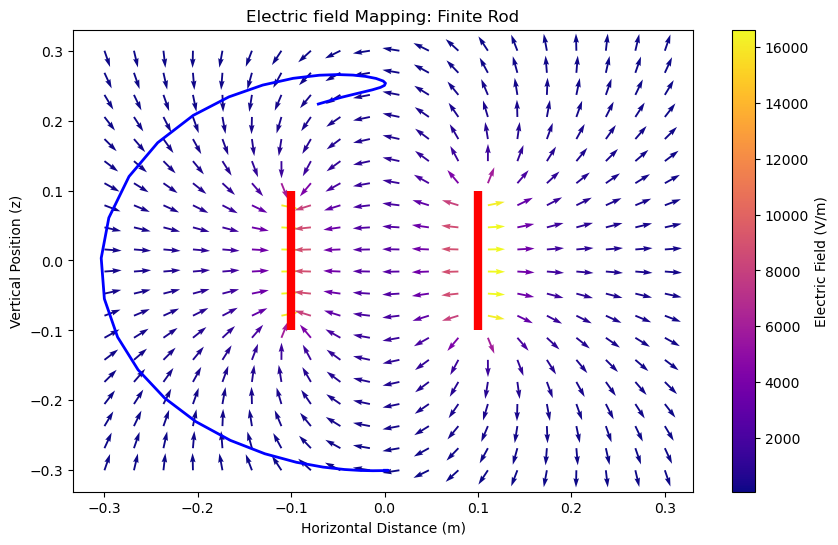

In [104]:
k_coulomb = 8.99e9  # N m^2 / C^2

def calculate_electric_field_Z(y, z_obs, y_obsA = 0.1, y_obsB = -0.1, L=0.2, lamA=1e-8, lamB = -1e-8): # Y compnent of electric field
# I independently calculated the integrand and integral of each rod and then summed the final value of their respective calculated E-fields
# sense there are two rods are offshoot from the origin you need a y_obs value that functions that same as the z_obs value, that's what my y value is
    def integrand_ZA(z_rod):    # Integrand for Z_component
        r_dist = np.sqrt((y-y_obsA)**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (z_obs- z_rod) / r_cubed 
    def integrand_ZB(z_rod):    # Integrand for Z_component
        r_dist = np.sqrt((y-y_obsB)**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (z_obs- z_rod) / r_cubed 
    
    n_segments = 100   # how many segments to divide it into
    z_points = np.linspace(-L/2 , L/2, n_segments)
    vZB_values = integrand_ZB(z_points)
    vZA_values = integrand_ZA(z_points)
    integral_zA = trapezoid(vZA_values, z_points)
    integral_zB = trapezoid(vZB_values, z_points)
    EzB = k_coulomb * lamB * integral_zB
    EzA = k_coulomb * lamA * integral_zA
    Net_Ez = EzB+EzA
    return Net_Ez

def calculate_electric_field_Y(y, z_obs, y_obsA = 0.1, y_obsB = -0.1, L=0.2, lamA=1e-8, lamB = -1e-8): # Y compnent of electric field

    def integrand_YA(z_rod): # Integrand for Y_component
        r_dist = np.sqrt((y-y_obsA)**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (y-y_obsA) / r_cubed 
    def integrand_YB(z_rod): # Integrand for Y_component
        r_dist = np.sqrt((y-y_obsB)**2 + (z_obs- z_rod)**2)  #Z/-rod is changing
        r_cubed = (r_dist)**3
        return (y-y_obsB) / r_cubed 

    
    n_segments = 100  # how many segments to divide it into
    z_points = np.linspace(-L/2, L/2, n_segments)
    vY_valuesA = integrand_YA(z_points)  
    vY_valuesB= integrand_YB(z_points)
    # Use the trapezoid rule to sum the contributions
    integral_yA = trapezoid(vY_valuesA, z_points)
    integral_yB = trapezoid(vY_valuesB, z_points)
    EyB = k_coulomb * lamB * integral_yB
    EyA = k_coulomb * lamA * integral_yA
    Net_Ey = EyB+EyA
    return Net_Ey
#Returned Ey and Ex so it would be easier to do math with the function
#E_mag = np.sqrt((Ey)**2 + (Ez)**2)  # combine z and y components in the end with magnitude equation


# 1. SETUP THE GRID (YZ-Plane)
y = np.linspace(-0.3, 0.30, 20)  # Perpendicular distance from the rod
z = np.linspace(-0.3, 0.3, 20)  # Position along/parallel to the rod
Y, Z = np.meshgrid(y, z)

# 2. CALCULATE Z AND Y components of the E-field AT EVERY GRID POINT
Ey_map = np.zeros(Y.shape)   #shape of Y
Ez_map = np.zeros(Z.shape)   #shape of Z
E_mag = np.zeros(Y.shape) # set 

for i in range(len(z)):   #len = length function looks at how many data points are in z_range 
    for j in range(len(y)): 
        E_mag[i,j] = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # array magnitude to allow for E_mag to be used on color map
        E_mag_x = np.sqrt((calculate_electric_field_Z(Y[i,j], Z[i,j]))**2 + (calculate_electric_field_Y(Y[i,j], Z[i,j]))**2) # scalar just to normalize data
        Ey_map[i,j] = calculate_electric_field_Y(Y[i,j], Z[i,j])/E_mag_x # Normlizes the data
        Ez_map[i,j] = calculate_electric_field_Z(Y[i,j], Z[i,j])/E_mag_x
       

qp = 1.602e-19
mp = 1.67e-27

def proton(t, state):
    y, z, vy, vz = state
    r_dist = np.sqrt((y)**2 + (z)**2)  #Z/-rod is changing
    r_cubed = (r_dist)**3
    Ey_p = calculate_electric_field_Y(y,z)  #already scaled correctly
    Ez_p = calculate_electric_field_Z(y,z)
    az = (Ez_p* qp)/mp
    ay = (Ey_p* qp)/mp
    return [vy, vz, ay, az]
   
y0 = [0.0, -0.3, 1e4, 0]  # slight nudge. I made it 2e4 because otherwise it had no noticable
t_span = (0, 1.4e-7)
t_span_p = (0, 2e-5)

sol_p = solve_ivp(proton, t_span_p, y0, method='RK45', rtol=1e-6)

zp_steps = sol_p.y[1]
yp_steps = sol_p.y[0]

#plots
plt.figure(figsize=(10, 6))
cp = plt.quiver(Y, Z, Ey_map, Ez_map, E_mag, cmap='plasma')
# Y,Z = origin point of where the vectors will be placed,  Ey_map,Ex_map = x and y components of vectors, E_mag sets the color map to the changing values of E_mag
plt.colorbar(cp, label='Electric Field (V/m)')
# Draw the charged rod
plt.vlines(0.1, -0.1, 0.1, color='red', linewidth=6, label= 'Charged Rod (L=0.2m)')
plt.vlines(-0.1, -0.1, 0.1, color='red', linewidth=6, label= 'Charged Rod (L=0.2m)')
plt.title("Electric field Mapping: Finite Rod")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Position (z)")
plt.plot(yp_steps, zp_steps, 'k-',alpha = 1, linewidth=2, label='Pendulum Angle', color= 'blue')